In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Weather Data Error Analysis v2

In [2]:
file_path = 'data/weather_data_2024-2026.csv'
file_path_fcst = 'data/weather_forecast_data_2024-2026.csv'
df = pd.read_csv(file_path)
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

df_fcst = pd.read_csv(file_path_fcst)
df_fcst['time'] = pd.to_datetime(df_fcst['time'])
df_fcst.set_index('time', inplace=True)

## 1. Actual Weather Data

In [3]:
df.head()

,site_id,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,direct_normal_irradiance,sunshine_duration
time,,,,,,,,,,,
2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.0,0.0
2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.0,0.0
2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.0,0.0
2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.0,0.0
2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.0,0.0


In [4]:
expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_timestamps = expected_index.difference(df.index)

print(f"Number of missing hours: {len(missing_timestamps)}")

Number of missing hours: 0


In [ ]:
# number of unique sites
unique_sites = df['site_id'].nunique()
print(f"Total number of unique sites: {unique_sites}")

# distribution of records per site
site_distribution = df['site_id'].value_counts().sort_index()

# Check if all sites have the same number of records
if site_distribution.nunique() == 1:
    print(f"\nAll {unique_sites} sites have the same number of records: {site_distribution.iloc[0]}")
else:
    print("\nSites have different numbers of records.")

Total number of unique sites: 151

All 151 sites have the same number of records: 19704


## 2. Forecast Weather Data

In [6]:
df_fcst.head()

,site_id,temperature_2m,apparent_temperature,relative_humidity_2m,precipitation,rain,snowfall,wind_speed_10m,shortwave_radiation,direct_normal_irradiance,sunshine_duration
time,,,,,,,,,,,
2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.0,0.0
2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.0,0.0
2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.0,0.0
2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.0,0.0
2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.0,0.0


In [7]:
expected_index = pd.date_range(start=df_fcst.index.min(), end=df_fcst.index.max(), freq='h')
missing_timestamps = expected_index.difference(df_fcst.index)

print(f"Number of missing hours: {len(missing_timestamps)}")

Number of missing hours: 0


In [8]:
fcst_diff = df_fcst.index.difference(df.index)
print(f"Number of timestamps in forecast but missing in actual data: {len(fcst_diff)}")

Number of timestamps in forecast but missing in actual data: 0


In [ ]:
# number of unique sites
unique_sites = df_fcst['site_id'].nunique()
print(f"Total number of unique sites: {unique_sites}")

# distribution of records per site
site_distribution = df_fcst['site_id'].value_counts().sort_index()

# Check if all sites have the same number of records
if site_distribution.nunique() == 1:
    print(f"\nAll {unique_sites} sites have the same number of records: {site_distribution.iloc[0]}")
else:
    print("\nSites have different numbers of records.")

Total number of unique sites: 151

All 151 sites have the same number of records: 19704


## 3. Error Analysis

In [10]:
df_merged = pd.merge(
    df,
    df_fcst,
    on=['time', 'site_id'],
    suffixes=("_actual", "_forecast"),
)
print(f"Actual 2024 rows: {len(df)}")
print(f"Forecast 2024 rows: {len(df_fcst)}")
print(f"Merged 2024 dataset shape: {df_merged.shape}")

Actual 2024 rows: 2975304
Forecast 2024 rows: 2975304
Merged 2024 dataset shape: (2975304, 21)


In [11]:
df_merged

,site_id,temperature_2m_actual,apparent_temperature_actual,relative_humidity_2m_actual,precipitation_actual,rain_actual,snowfall_actual,wind_speed_10m_actual,shortwave_radiation_actual,direct_normal_irradiance_actual,...,temperature_2m_forecast,apparent_temperature_forecast,relative_humidity_2m_forecast,precipitation_forecast,rain_forecast,snowfall_forecast,wind_speed_10m_forecast,shortwave_radiation_forecast,direct_normal_irradiance_forecast,sunshine_duration_forecast
time,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,1,7.85,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.00000,...,7.850000,0.968274,72.439610,0.0,0.0,0.0,10.104455,0.0,0.00000,0.0000
2024-01-01 01:00:00,1,8.25,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.00000,...,8.250000,1.397761,70.000916,0.0,0.0,0.0,10.012492,0.0,0.00000,0.0000
2024-01-01 02:00:00,1,7.95,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.00000,...,7.950000,1.164671,70.938260,0.0,0.0,0.0,9.849365,0.0,0.00000,0.0000
2024-01-01 03:00:00,1,6.55,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.00000,...,6.550000,0.291983,82.887200,0.1,0.1,0.0,9.154780,0.0,0.00000,0.0000
2024-01-01 04:00:00,1,7.05,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.00000,...,7.050000,0.588700,82.370926,1.3,1.3,0.0,9.693812,0.0,0.00000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-31 19:00:00,152,9.50,7.060910,70.743670,0.0,0.0,0.0,2.110095,88.0,41.29726,...,9.960501,7.421904,76.000000,0.0,0.0,0.0,2.900000,221.0,433.26900,3600.0000
2026-03-31 20:00:00,152,8.25,6.202212,79.705170,0.0,0.0,0.0,1.562050,50.0,117.47925,...,8.560500,6.435931,82.000000,0.0,0.0,0.0,2.000000,66.0,169.25354,3468.3018
2026-03-31 21:00:00,152,6.25,3.946887,87.636770,0.0,0.0,0.0,1.811767,1.0,0.00000,...,6.910500,4.342035,85.000000,0.0,0.0,0.0,2.400000,1.0,0.00000,0.0000


### 3.1 MAE and Relative Error Rate

In [ ]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

vars_to_plot = [
    'temperature_2m', 'apparent_temperature', 'relative_humidity_2m',
    'precipitation', 'rain', 'snowfall', 'wind_speed_10m',
    'shortwave_radiation', 'direct_normal_irradiance', 'sunshine_duration'
]

errors = {}

for col in vars_to_plot:
    mae = mean_absolute_error(df_merged[f"{col}_actual"], df_merged[f"{col}_forecast"])
    rmse = root_mean_squared_error(df_merged[f"{col}_actual"], df_merged[f"{col}_forecast"])
    mape = mean_absolute_percentage_error(df_merged[f"{col}_actual"], df_merged[f"{col}_forecast"])

    # Normalized MAE and RMSE
    data_range = df_merged[f"{col}_actual"].max() - df_merged[f"{col}_actual"].min()
    nrmse_pct = (rmse / data_range * 100) if data_range > 0 else 0
    nmae_pct = (mae / data_range * 100) if data_range > 0 else 0

    print(f"{col}: MAE = {mae:.2f}, RMSE = {rmse:.2f}, MAPE = {mape:.2f}, nRMSE (%) = {nrmse_pct:.2f}%, nMAE (%) = {nmae_pct:.2f}%")
    errors[col] = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'nRMSE': nrmse_pct, 'nMAE': nmae_pct}

error_df = pd.DataFrame(errors).T
error_df

temperature_2m: MAE = 0.67, RMSE = 1.01, MAPE = 2947830026547.69, nRMSE (%) = 2.10%, nMAE (%) = 1.40%
apparent_temperature: MAE = 0.74, RMSE = 1.09, MAPE = 0.56, nRMSE (%) = 2.06%, nMAE (%) = 1.39%
relative_humidity_2m: MAE = 4.72, RMSE = 7.87, MAPE = 0.07, nRMSE (%) = 9.37%, nMAE (%) = 5.62%
precipitation: MAE = 0.08, RMSE = 0.44, MAPE = 81789576240016.55, nRMSE (%) = 2.02%, nMAE (%) = 0.38%
rain: MAE = 0.08, RMSE = 0.40, MAPE = 51905531758103.75, nRMSE (%) = 1.86%, nMAE (%) = 0.35%
snowfall: MAE = 0.00, RMSE = 0.05, MAPE = 265208427937.52, nRMSE (%) = 0.81%, nMAE (%) = 0.04%
wind_speed_10m: MAE = 0.54, RMSE = 0.80, MAPE = 369787218034.62, nRMSE (%) = 5.31%, nMAE (%) = 3.58%
shortwave_radiation: MAE = 23.57, RMSE = 63.79, MAPE = 4260953822213.92, nRMSE (%) = 7.04%, nMAE (%) = 2.60%
direct_normal_irradiance: MAE = 52.07, RMSE = 119.21, MAPE = 4359989195678780.50, nRMSE (%) = 12.57%, nMAE (%) = 5.49%
sunshine_duration: MAE = 279.84, RMSE = 895.31, MAPE = 238932267926736608.00, nRMSE (%)

,MAE,RMSE,MAPE,nRMSE,nMAE
temperature_2m,0.673005,1.005043,2.947830e+12,2.096023,1.403556
apparent_temperature,0.737628,1.090808,5.563755e-01,2.059767,1.392859
relative_humidity_2m,4.717711,7.866715,6.625673e-02,9.374469,5.621919
precipitation,0.081526,0.436585,8.178958e+13,2.021228,0.377437
rain,0.076424,0.400783,5.190553e+13,1.855475,0.353813
snowfall,0.002577,0.049619,2.652084e+11,0.805502,0.041832
wind_speed_10m,0.537230,0.797406,3.697872e+11,5.306701,3.575240
shortwave_radiation,23.568674,63.794392,4.260954e+12,7.041324,2.601399
direct_normal_irradiance,52.072521,119.211803,4.359989e+15,12.572867,5.491913
sunshine_duration,279.844189,895.307364,2.389323e+17,24.869649,7.773450


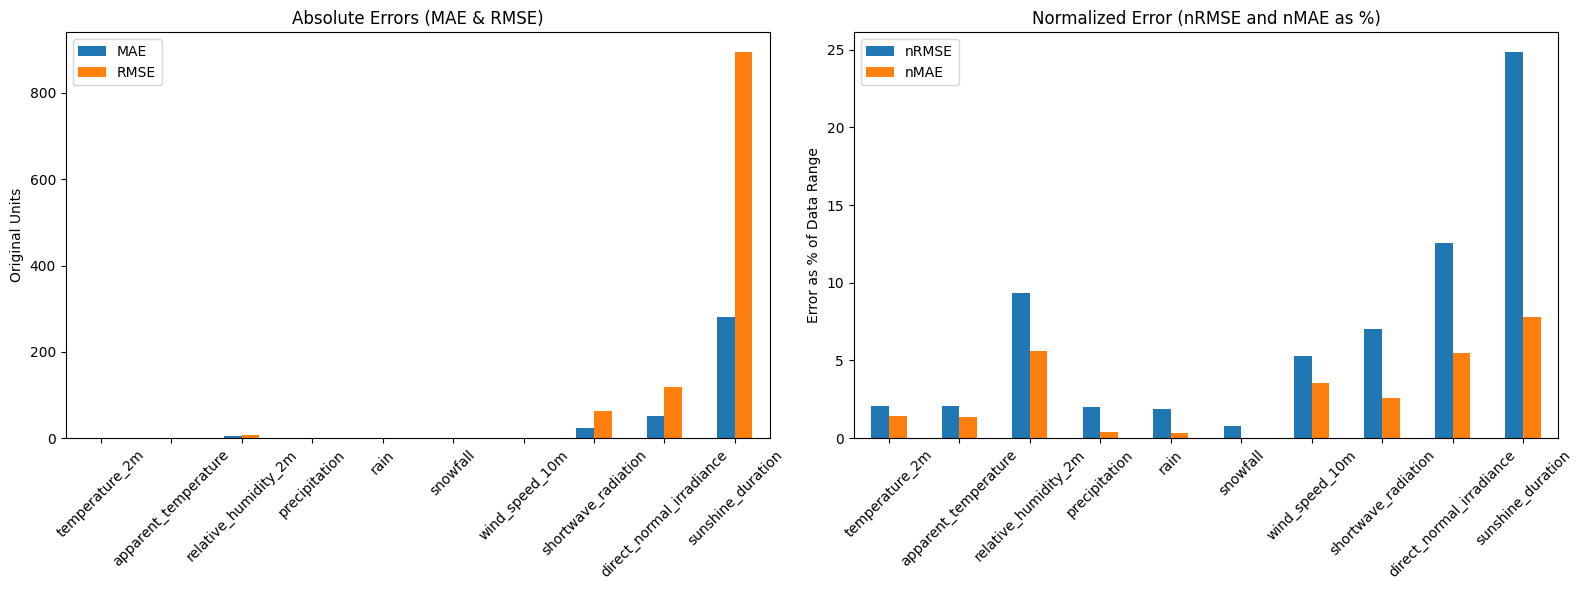

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Plot MAE and RMSE
error_df[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], title='Absolute Errors (MAE & RMSE)')
axes[0].set_ylabel('Original Units')
axes[0].tick_params(axis='x', rotation=45)

# Plot Normalized RMSE (%)
error_df[['nRMSE', 'nMAE']].plot(kind='bar', ax=axes[1], title='Normalized Error (nRMSE and nMAE as %)')
axes[1].set_ylabel('Error as % of Data Range')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [20]:
error_df.nMAE.mean()

np.float64(2.8633416424059153)

In [14]:
monthly_error_data = {col: {} for col in vars_to_plot}

for col in vars_to_plot:
    actual = df_merged[f"{col}_actual"]
    forecast = df_merged[f"{col}_forecast"]

    abs_error = (actual - forecast).abs()
    sq_error = (actual - forecast) ** 2

    data_range = actual.max() - actual.min()

    grouped_abs = abs_error.groupby([df_merged.index.month, df_merged.index.year])
    grouped_sq = sq_error.groupby([df_merged.index.month, df_merged.index.year])

    monthly_mae = grouped_abs.mean()
    monthly_rmse = grouped_sq.mean().apply(np.sqrt)
    monthly_nmae = (
        (monthly_mae / data_range * 100) if data_range > 0 else monthly_mae * 0
    )
    monthly_nrmse = (
        (monthly_rmse / data_range * 100) if data_range > 0 else monthly_rmse * 0
    )

    monthly_error_data[col]["MAE"] = monthly_mae
    monthly_error_data[col]["RMSE"] = monthly_rmse
    monthly_error_data[col]["nMAE"] = monthly_nmae
    monthly_error_data[col]["nRMSE"] = monthly_nrmse

# Build a MultiIndex column DataFrame: (variable, metric)
monthly_mae_df = pd.concat(
    {col: pd.DataFrame(metrics) for col, metrics in monthly_error_data.items()}, axis=1
)
monthly_mae_df.index.names = ["Month", "Year"]
monthly_mae_df = monthly_mae_df.reset_index()

monthly_mae_df

Month  Year temperature_2m                                \
                          MAE      RMSE      nMAE     nRMSE   
0      1  2024       0.000000  0.000000  0.000000  0.000000   
1      1  2025       0.833639  1.141377  1.738558  2.380349   
2      1  2026       0.705541  0.908289  1.471409  1.894241   
3      2  2024       0.000000  0.000000  0.000000  0.000000   
4      2  2025       0.771286  1.008585  1.608521  2.103409   
5      2  2026       0.672162  0.877717  1.401797  1.830483   
6      3  2024       0.000000  0.000000  0.000000  0.000000   
7      3  2025       1.043424  1.349097  2.176066  2.813549   
8      3  2026       0.787329  1.038302  1.641979  2.165385   
9      4  2024       0.000000  0.000000  0.000000  0.000000   
10     4  2025       0.950016  1.217853  1.981263  2.539839   
11     5  2024       0.000000  0.000000  0.000000  0.000000   
12     5  2025       0.920850  1.218444  1.920438  2.541072   
13     6  2024       0.204962  0.657261  0.427450  1.370721   
14     6  2025       0.976477  1.287928  2.036447  2.685982   
15     7  2024       1.098375  1.449352  2.290667  3.022632   
16     7  2025       1.027328  1.322138  2.142498  2.757327   
17     8  2024       0.993046  1.315258  2.071004  2.742978   
18     8  2025       0.959404  1.225721  2.000843  2.556249   
19     9  2024       0.867603  1.144519  1.809390  2.386900   
20     9  2025       0.829799  1.073706  1.730550  2.239220   
21    10  2024       0.815994  1.062769  1.701761  2.216411   
22    10  2025       0.665982  0.876005  1.388909  1.826913   
23    11  2024       0.854085  1.141715  1.781199  2.381053   
24    11  2025       0.695951  0.892604  1.451411  1.861530   
25    12  2024       0.716340  0.927759  1.493930  1.934846   
26    12  2025       0.747389  0.955790  1.558684  1.993305   

   apparent_temperature                                ...  \
                    MAE      RMSE      nMAE     nRMSE  ...   
0              0.000000  0.000000  0.000000  0.000000  ...   
1              0.951358  1.277392  1.796444  2.412093  ...   
2              0.803662  1.030541  1.517551  1.945965  ...   
3              0.000000  0.000000  0.000000  0.000000  ...   
4              0.880191  1.142330  1.662060  2.157055  ...   
5              0.778029  1.003306  1.469147  1.894537  ...   
6              0.000000  0.000000  0.000000  0.000000  ...   
7              1.111635  1.436469  2.099095  2.712477  ...   
8              0.892942  1.155341  1.686137  2.181623  ...   
9              0.000000  0.000000  0.000000  0.000000  ...   
10             0.915803  1.188186  1.729306  2.243644  ...   
11             0.000000  0.000000  0.000000  0.000000  ...   
12             0.991166  1.315839  1.871613  2.484691  ...   
13             0.100228  0.458445  0.189260  0.865678  ...   
14             1.036589  1.359888  1.957385  2.567869  ...   
15             1.213147  1.551962  2.290779  2.930561  ...   
16             1.050524  1.341133  1.983698  2.532455  ...   
17             1.147140  1.481281  2.166139  2.797095  ...   
18             0.970714  1.245130  1.832994  2.351172  ...   
19             1.019903  1.303910  1.925877  2.462166  ...   
20             0.853261  1.089805  1.611208  2.057872  ...   
21             0.954585  1.235729  1.802538  2.333420  ...   
22             0.741078  0.980435  1.399374  1.851349  ...   
23             0.981192  1.296499  1.852780  2.448172  ...   
24             0.801881  1.030142  1.514187  1.945212  ...   
25             0.854781  1.102466  1.614078  2.081780  ...   
26             0.830066  1.066668  1.567408  2.014183  ...   

   shortwave_radiation            direct_normal_irradiance              \
                  nMAE      nRMSE                      MAE        RMSE   
0             0.000000   0.000000                 0.000000    0.000000   
1             1.246592   3.167021                36.421342   99.395542   
2             1.173824   3.135203                39.302475   99.507865   
3     

In [15]:
monthly_mae_df.to_csv('data/monthly_error_analysis.csv')

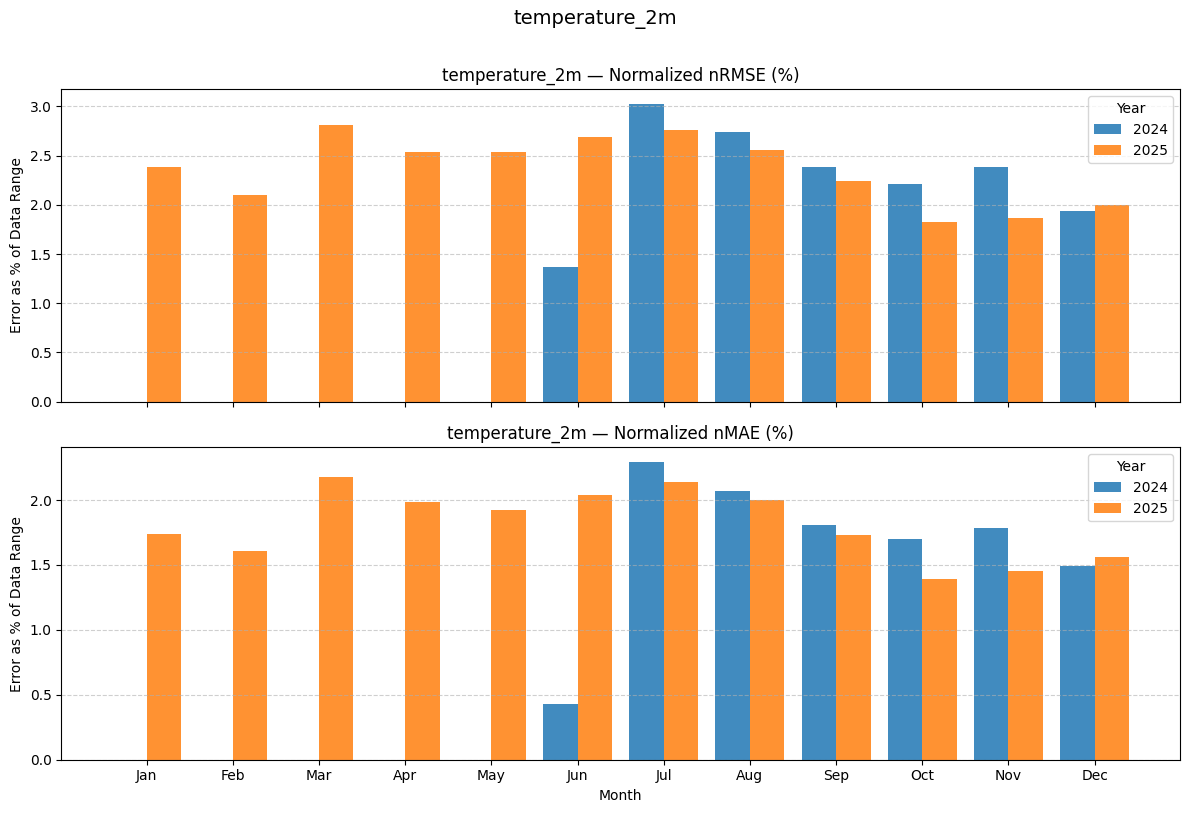

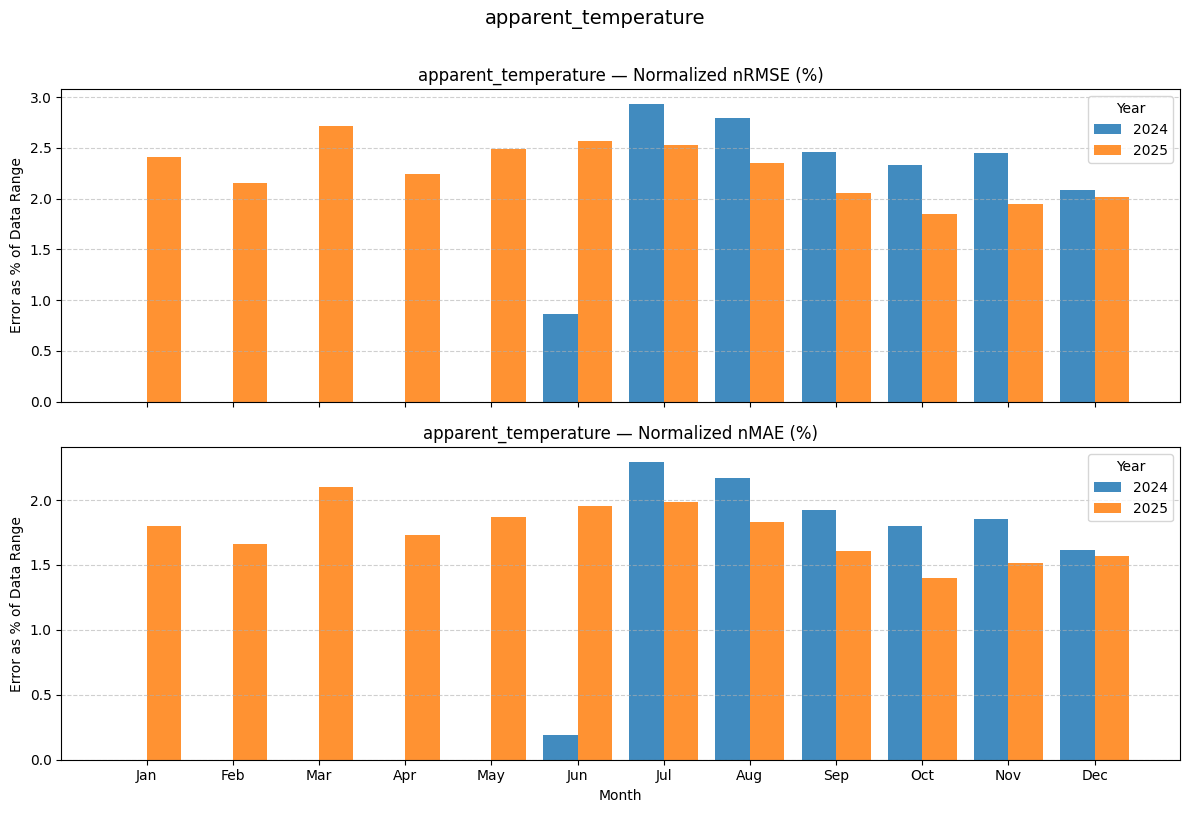

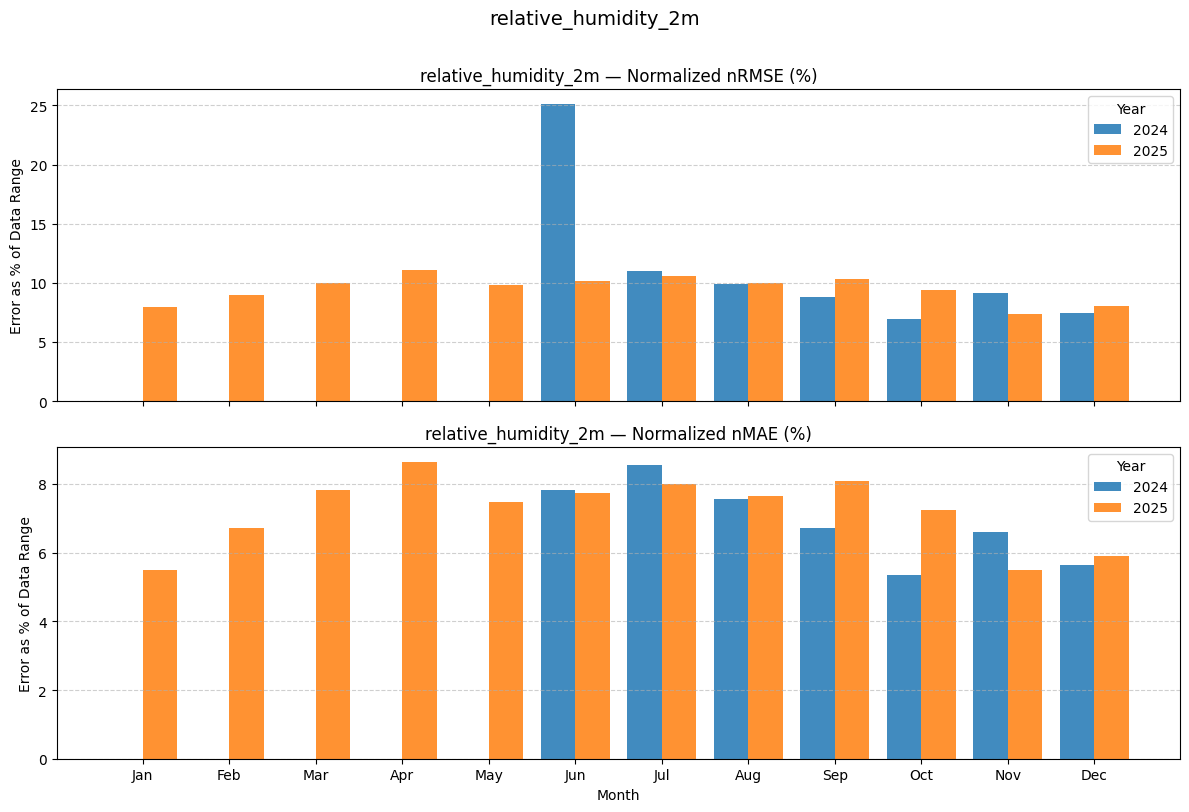

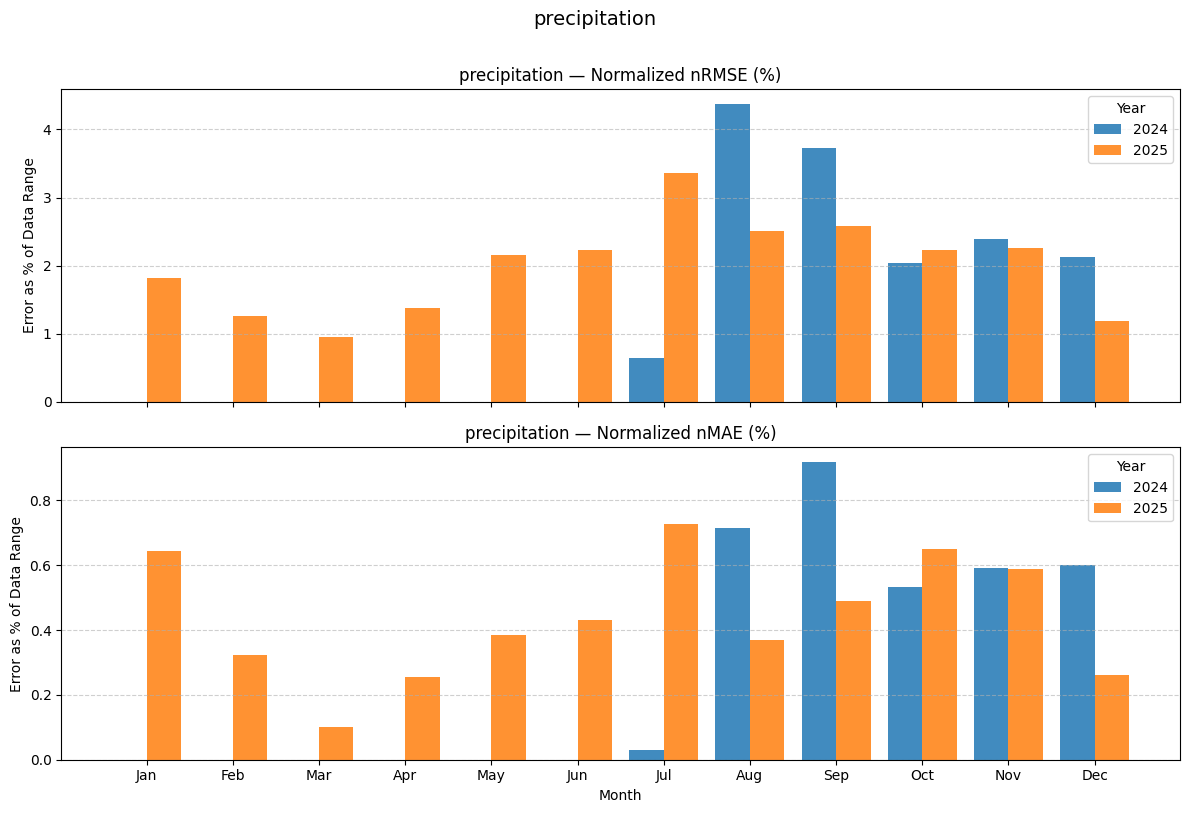

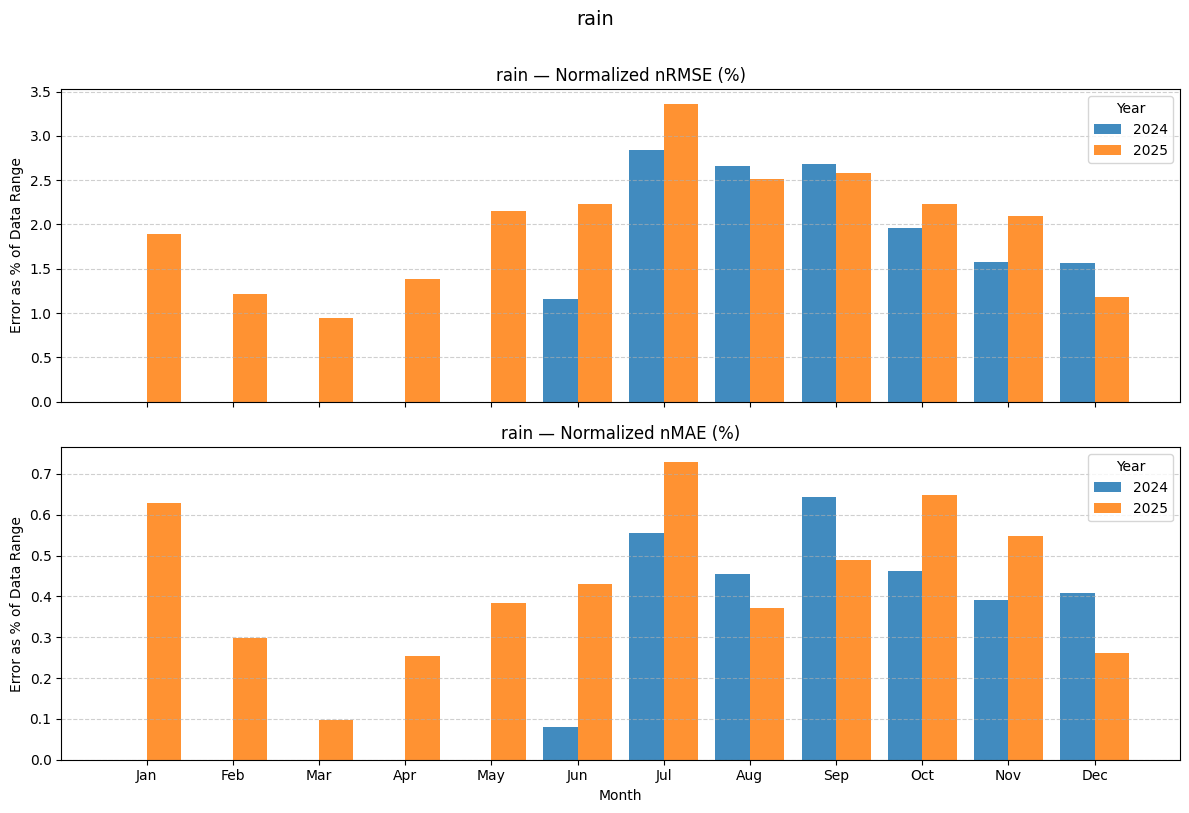

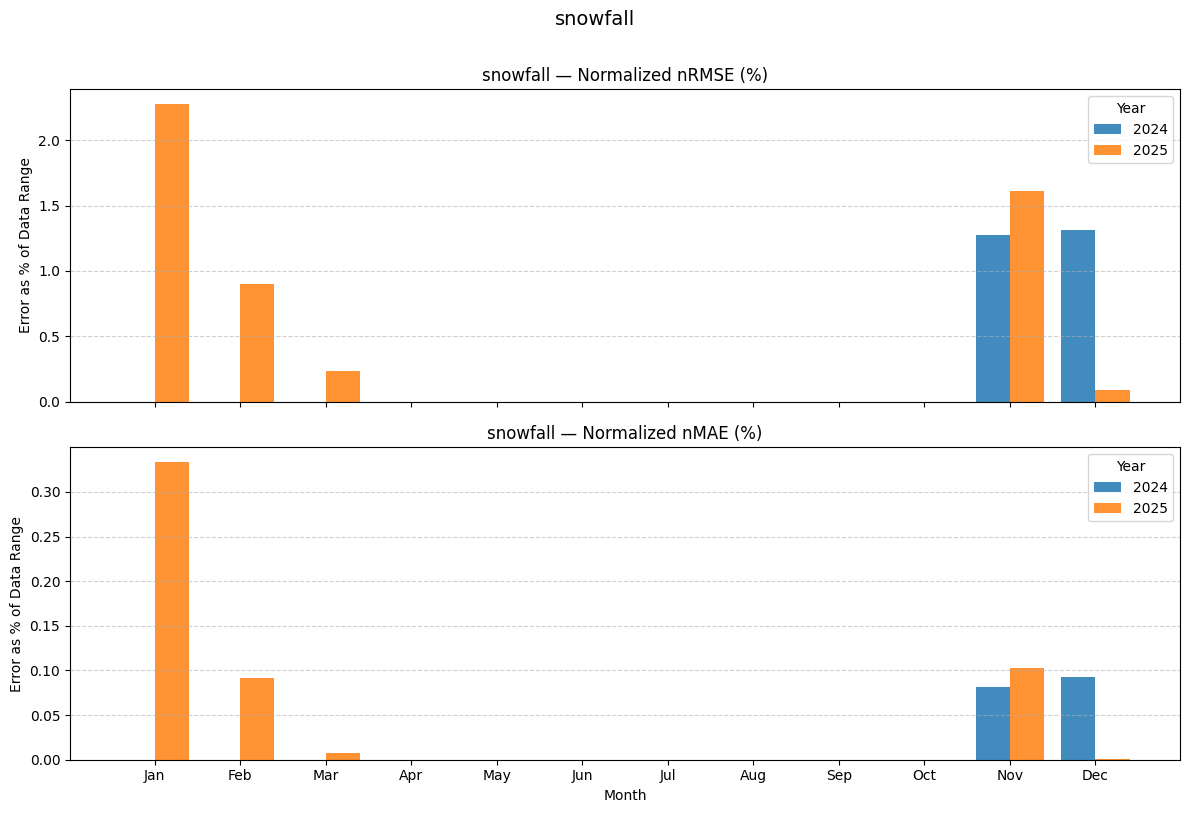

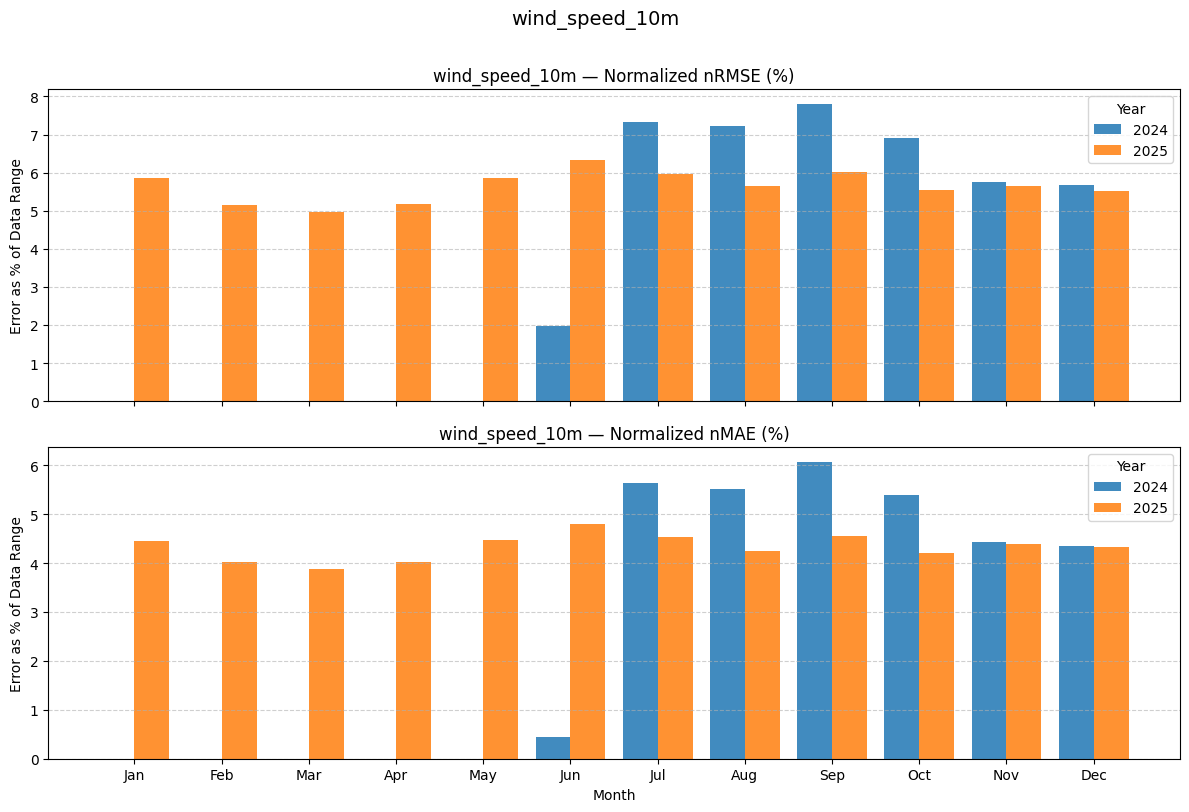

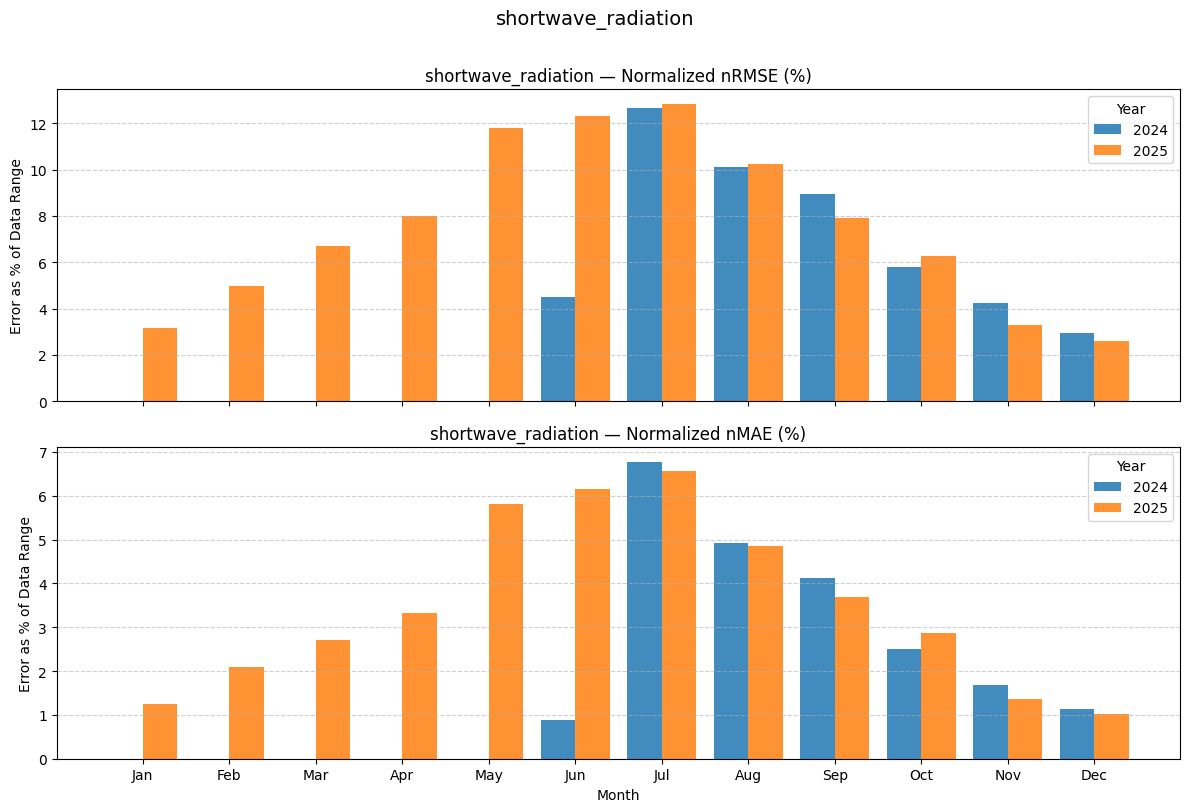

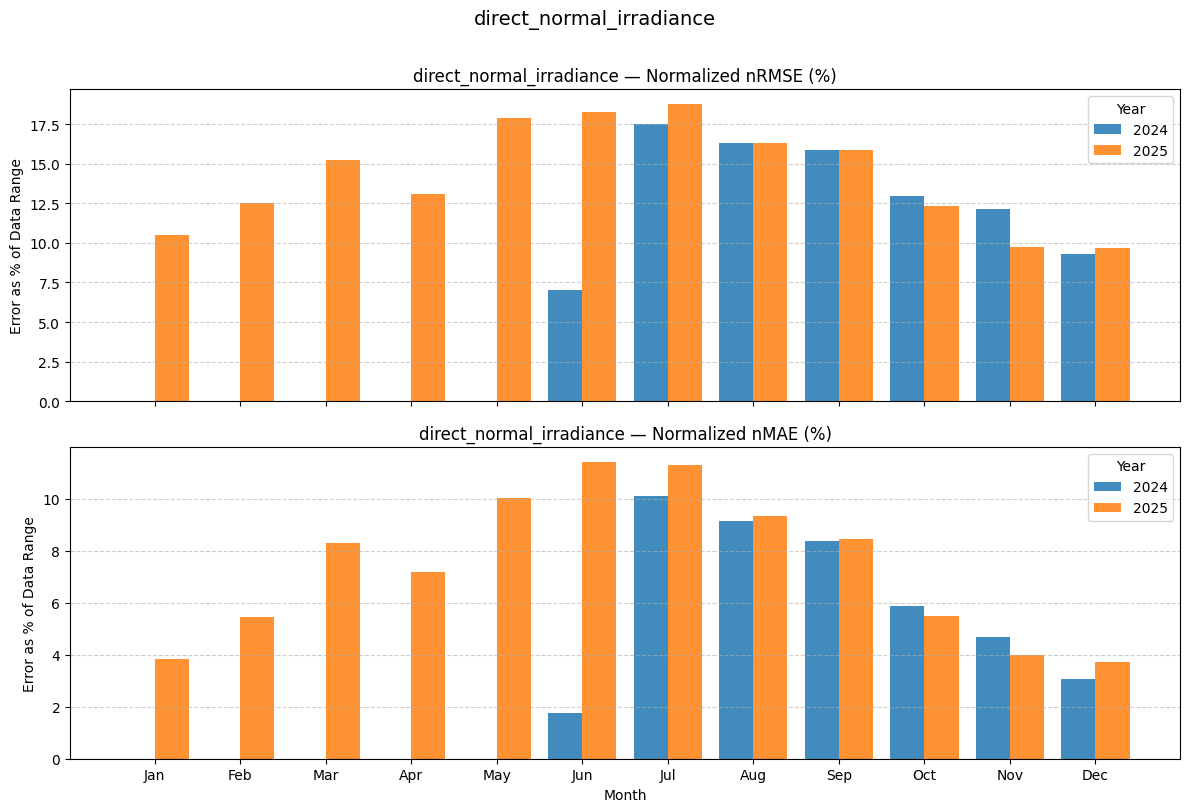

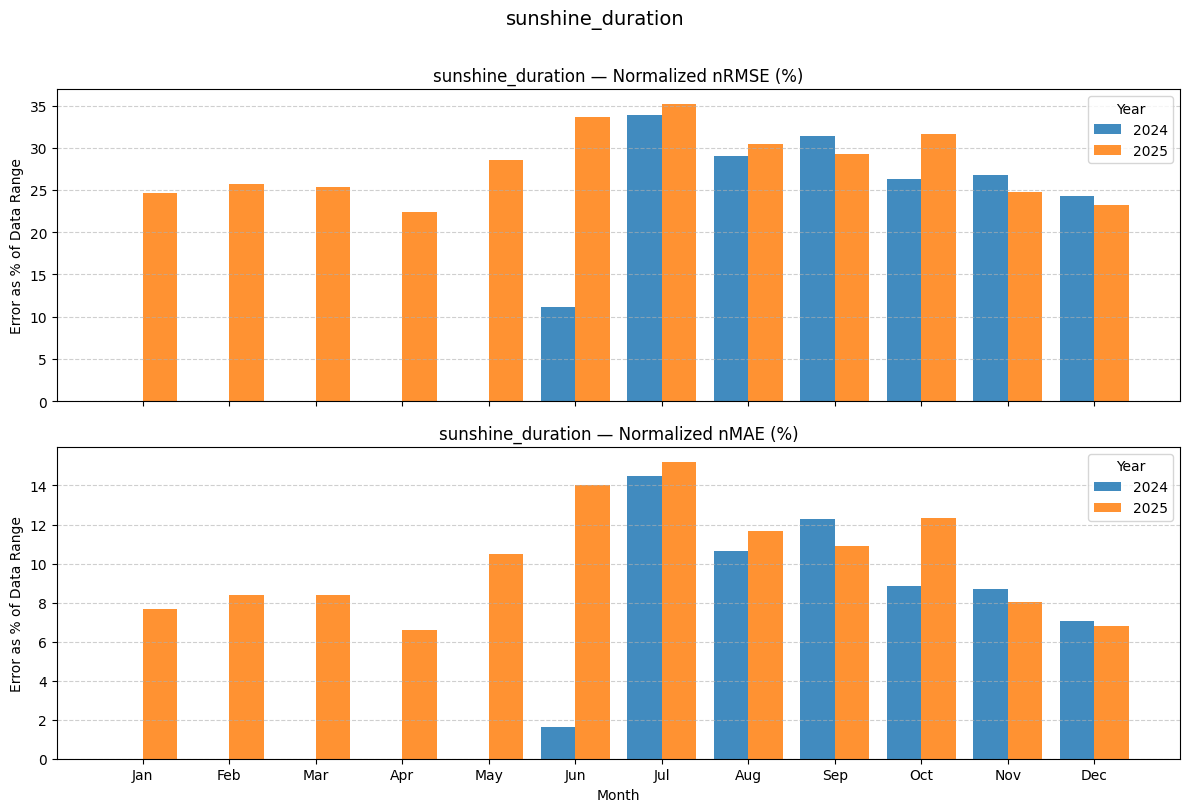

In [16]:
for col in vars_to_plot:
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # Slice the variable's metrics and re-attach Month/Year
    col_df = monthly_mae_df[["Month", "Year"]].copy()
    col_df["nRMSE"] = monthly_mae_df[(col, "nRMSE")]
    col_df["nMAE"] = monthly_mae_df[(col, "nMAE")]

    years = [2024, 2025]
    n_years = len(years)
    palette = sns.color_palette("tab10", n_years)
    x = np.arange(12)
    width = 0.8 / n_years
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

    for ax, metric in zip(axes, ["nRMSE", "nMAE"]):
        for j, (year, color) in enumerate(zip(years, palette)):
            subset = col_df[col_df["Year"] == year].sort_values("Month")
            offsets = subset["Month"].values - 1
            ax.bar(
                offsets + j * width - (n_years - 1) * width / 2,
                subset[metric].values,
                width=width,
                label=str(year),
                color=color,
                alpha=0.85,
            )

        ax.set_title(f"{col} — Normalized {metric} (%)", fontsize=12)
        ax.set_ylabel("Error as % of Data Range")
        ax.set_xticks(x)
        ax.set_xticklabels(month_labels)
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")
        ax.legend(title="Year")

    plt.xlabel("Month")
    plt.suptitle(col, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

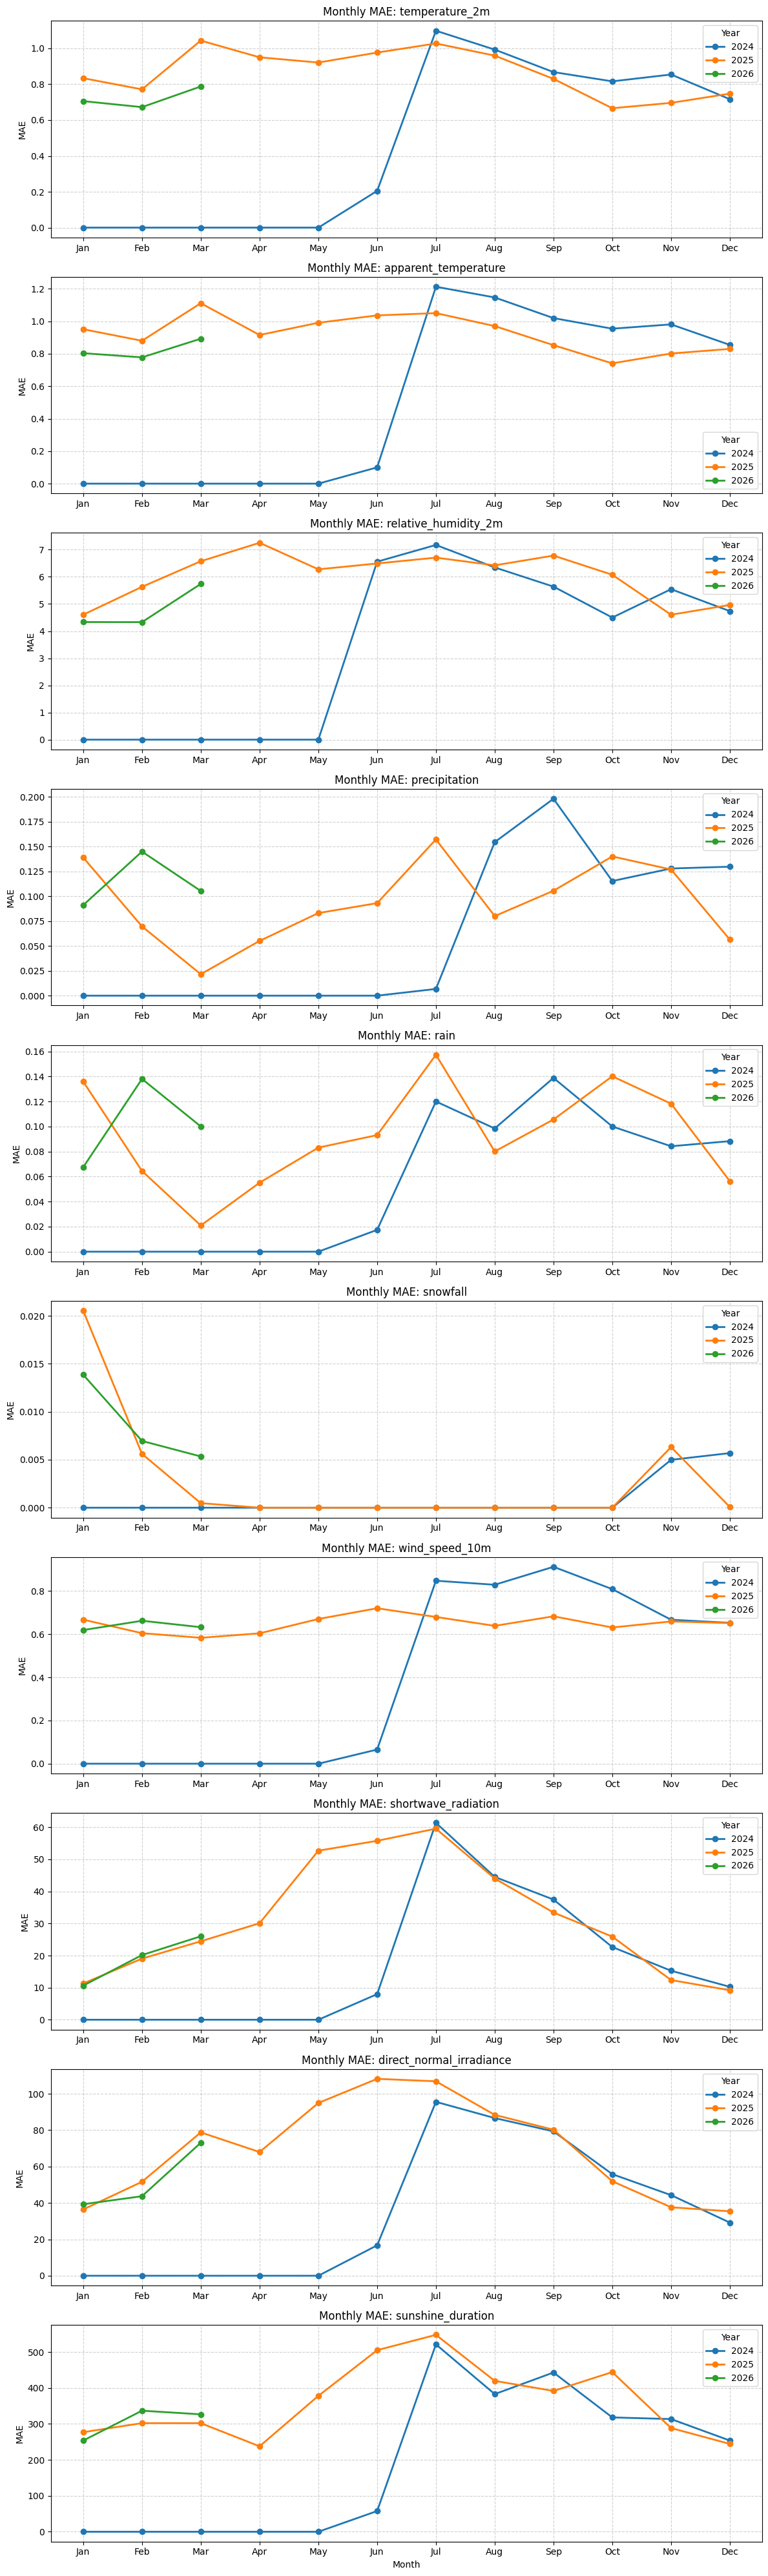

In [17]:
n_vars = len(vars_to_plot)
fig, axes = plt.subplots(n_vars, 1, figsize=(12, 4 * n_vars), sharex=False)
if n_vars == 1:
    axes = [axes]

years = sorted(monthly_mae_df['Year'].unique())
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_mae_df.columns = [f"{col}_{metric}" if metric else col 
                           for col, metric in monthly_mae_df.columns]

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    for year in years:
        subset = monthly_mae_df[monthly_mae_df['Year'] == year].sort_values('Month')
        ax.plot(subset['Month'], subset[f'{var}_MAE'], marker='o', label=str(year), linewidth=2)

    ax.set_title(f'Monthly MAE: {var}', fontsize=12)
    ax.set_ylabel('MAE')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(title='Year')

plt.xlabel('Month')
plt.tight_layout()
plt.show()